# NeuroAtlas: a minimal reproduction

NeuroAtlas asks one question: are EEG foundation models actually good at EEG? This
notebook runs the evaluation that answers it, on a slice small enough for one machine.
Every stage is a short cell you can inspect before moving on.

The pipeline is the same six steps for every task:

    EDF -> labelled epochs -> channel mapping -> frozen embeddings -> linear probe -> metrics

Only the last step differs between tasks, and it differs a lot:

| Task | Dataset | Reported |
|---|---|---|
| Sleep staging | Sleep-EDF Expanded | accuracy and kappa, then a hypnogram and clinical features |
| Brain age | Sleep-EDF Expanded | mean absolute error and the brain age gap |
| Seizure detection | CHB-MIT | event sensitivity and false alarms per hour |

**What you need:** two public datasets, about 30 GB, no credentials. You do not need model
weights — everything used here downloads on first run. Section 4 shows which models are
reachable and which need the undistributed `artifacts/`.

**How long:** about two and a half minutes on one GPU at default settings. `SUBJECT_LIMIT`
(section 5) and `LIMIT_BATCHES` (section 7d) trade runtime for how seriously you can take
the numbers; both default to small.

This is a guided tour of the protocol on one fold with one seed, not a rerun of the paper's
tables. Section 8 lists every shortcut.


## 0. Setting up

One Python 3.11 kernel and this:

```bash
pip install numpy scipy pandas scikit-learn matplotlib torch \
            edfio h5py pyyaml xlrd transformers safetensors momentfm chronos-forecasting \
            easydict
```

`pyyaml` reads the channel maps in section 3; `xlrd` opens Sleep-EDF's legacy `.xls` age
table. No `mne`, `braindecode` or `physioex` — both sleep tasks read EDF directly through
`edfio`. No jax or uni2ts either: MOMENT and Chronos are ordinary torch plus transformers.


In [1]:
import importlib
import platform
import sys
import warnings
from pathlib import Path

REQUIRED = ["numpy", "scipy", "pandas", "sklearn", "matplotlib", "torch",
            "edfio", "h5py", "yaml", "xlrd", "transformers", "safetensors",
            "momentfm", "chronos", "easydict"]
PIP_NAMES = {"sklearn": "scikit-learn", "yaml": "pyyaml", "chronos": "chronos-forecasting"}

print(f"python {platform.python_version()}")
# Name only: an executed copy of this notebook is committed, and the full
# interpreter path would put someone's home directory in git.
print(f"kernel {Path(sys.executable).parent.parent.name}\n")

# tqdm prints an IProgress warning that quotes its install path, for the same
# reason, and it is noise in a notebook that is not using widgets.
warnings.filterwarnings("ignore", message=".*IProgress.*")

missing = []
for name in REQUIRED:
    try:
        module = importlib.import_module(name)
        print(f"  ok      {name:14s} {getattr(module, '__version__', 'installed')}")
    except Exception as exc:
        print(f"  absent  {name:14s} ({type(exc).__name__})")
        missing.append(name)

if missing:
    raise SystemExit("Install the missing packages first:\n  pip install "
                     + " ".join(PIP_NAMES.get(name, name) for name in missing))
print("\nEnvironment is complete.")


python 3.11.15
kernel eegbenchmarks

  ok      numpy          2.4.4
  ok      scipy          1.17.1


  ok      pandas         3.0.2


  ok      sklearn        1.7.2
  ok      matplotlib     3.10.7


  ok      torch          2.7.1+cu128
  ok      edfio          0.4.13
  ok      h5py           3.15.1
  ok      yaml           6.0.3
  ok      xlrd           2.0.2


  ok      transformers   4.57.1
  ok      safetensors    0.7.0


  ok      momentfm       installed
  ok      chronos        installed
  ok      easydict       installed

Environment is complete.


### Where your data is

`REPO_ROOT` is your checkout. Set the two data roots through the environment if you keep
corpora outside the repository.


In [2]:
import os
from pathlib import Path

REPO_ROOT = Path(os.environ.get("NEUROATLAS_ROOT", Path.cwd().parent)).resolve()
if not (REPO_ROOT / "configs" / "folds").is_dir():
    raise SystemExit(f"{REPO_ROOT} is not a NeuroAtlas checkout. Set NEUROATLAS_ROOT.")
sys.path.insert(0, str(REPO_ROOT / "src"))

SLEEPEDF_ROOT = Path(os.environ.get(
    "SLEEPEDF_ROOT", REPO_ROOT / "data" / "sleep-edf-database-expanded-1.0.0"))
CHBMIT_ROOT = Path(os.environ.get("CHBMIT_ROOT", REPO_ROOT / "chbmit_cache" / "raw"))

WORK = REPO_ROOT / "artifacts" / "minimal_repro"
WORK.mkdir(parents=True, exist_ok=True)

FOLD = 0        # single fold, taken from configs/folds/
SEED = 0

# Sleep is scored in 30 s epochs, which is the clinical convention and what the
# Sleep-EDF hypnograms annotate. Seizure detection uses 10 s windows with a 10 s
# stride, the w10s_s10s setting the epilepsy runners use; see the note in section 1.
EPOCH_SECONDS = 30.0
CHBMIT_WINDOW_SECONDS = 10.0
# The supervised seizure baseline was pretrained on the 19 channel unipolar 10-20
# montage, so it rejects bipolar pair names. Use unipolar so both it and the
# foundation models see the same input.
CHBMIT_MONTAGE = "unipolar"

def show(path):
    """Relative to the repository when possible, so an executed copy of this
    notebook does not carry someone's absolute home directory into git."""
    try:
        return f"<repo>/{path.relative_to(REPO_ROOT)}"
    except ValueError:
        return f"<external>/{path.name}"

for label, path in [("repository", REPO_ROOT), ("Sleep-EDF", SLEEPEDF_ROOT),
                    ("CHB-MIT", CHBMIT_ROOT), ("outputs", WORK)]:
    state = "found" if path.exists() else "not downloaded yet"
    print(f"  {label:11s} {show(path):46s} [{state}]")


  repository  <repo>/.                                       [found]
  Sleep-EDF   <external>/sleepedf                            [found]
  CHB-MIT     <external>/chbmit                              [found]
  outputs     <repo>/artifacts/minimal_repro                 [found]


### Getting the data

Sleep-EDF Expanded, from PhysioNet, about 8 GB — used in sections 5 to 7:

```bash
wget -r -N -c -np -nH --cut-dirs=1 -P "$(dirname "$SLEEPEDF_ROOT")" \
     https://physionet.org/files/sleep-edfx/1.0.0/
```

CHB-MIT, from Zenodo under ODC-BY, about 22 GB — used in section 7d:

```bash
mkdir -p "$CHBMIT_ROOT" && cd "$CHBMIT_ROOT"
curl -L -o BIDS_CHB-MIT.zip \
     "https://zenodo.org/records/10259996/files/BIDS_CHB-MIT.zip?download=1"
unzip -q BIDS_CHB-MIT.zip        # yields $CHBMIT_ROOT/BIDS_CHB-MIT/sub-01 ...
```

That is Zenodo record 10259996, the SzCORE BIDS conversion rather than the raw
PhysioNet release; every loader here expects the BIDS form. `fetch --dataset chbmit`
prints the same thing from the manifest.

CHB-MIT stands in for TUSZ, the paper's epilepsy cohort, which needs a signed Temple
University agreement and so cannot appear in a notebook anyone can run. The task and the
event metrics are identical; the absolute numbers are not comparable.


## 1. Who trains, who is tested

Every number below depends on one decision: which people the model learns from, and which
it is judged on. So it comes first, before any EEG file is opened.

The splits are **not** computed here. They were decided once, written to
`configs/folds/`, and committed. This notebook reads them as they are — which is the only
way your results can be compared with the paper's. Recomputing them would let a library
version or a seed quietly change who is in which group.

Each file holds five folds; this notebook uses fold 0 throughout.


In [3]:
from benchmarking_helpers.registry.fold_manifest import (
    SPLIT_RULE,
    check_subject_grouping,
    load_fold_split,
)

SLEEP_MANIFEST = "sleep_edf_expanded"
CHBMIT_MANIFEST = "chbmit"

sleep_split = load_fold_split(SLEEP_MANIFEST, FOLD)
chbmit_split = load_fold_split(CHBMIT_MANIFEST, FOLD)

print(f"Derivation rule for partition style manifests:\n  {SPLIT_RULE}\n")
for split in (sleep_split, chbmit_split):
    print(split.summary())
    print(f"    read from {split.source_path.relative_to(REPO_ROOT)}")


Derivation rule for partition style manifests:
  test=folds[k]; val=folds[(k+1) % n]; train=rest

sleep_edf_expanded fold 0/5 [explicit]: 113 train / 42 val / 42 test subjects (197 total)
    read from configs/cohorts/sleep_edf_expanded/folds.json
chbmit fold 0/5 [explicit]: 14 train / 4 val / 5 test subjects (23 total)
    read from configs/cohorts/chbmit/folds.json


### Check one: is a subject on both sides of the split?

Manifests list *recordings*, not subjects, and Sleep-EDF Cassette records two nights per
person. A split that is perfectly disjoint over recordings can still put night 1 in
training and night 2 in test, which inflates every number that follows.

This is not hypothetical: an earlier Sleep-EDF manifest here split per recording and put
62 percent of its fold-0 test subjects into training too. It was removed once this check
existed. Below, the manifest we use is verified clean, then deliberately broken to show
what the check catches. Run it against any manifest you add.


In [4]:
# Sleep-EDF recording ids look like SC4001E0 or ST7011J0, where the two digits after the
# three character prefix identify the subject and the next digit is the night.
recording_to_subject = lambda recording_id: recording_id[:5]

report = check_subject_grouping(sleep_split, recording_to_subject)
print(f"{SLEEP_MANIFEST}: clean")
print(f"  {report['n_recordings']} recordings from {report['n_subjects']} subjects, "
      f"no subject on both sides of any split\n")

# What the check looks like when a split IS leaky. Take one subject who has two
# recordings in test and move the second into train -- the split stays disjoint over
# recordings, which is exactly what makes this failure easy to miss.
from collections import Counter
from dataclasses import replace

nights = Counter(recording_to_subject(r) for r in sleep_split.test)
two_nights = next((s for s, n in nights.items() if n > 1), None)
if two_nights is None:
    print("\n(no subject has two nights in this fold's test split; nothing to demonstrate)")
else:
    moved = [r for r in sleep_split.test if recording_to_subject(r) == two_nights][-1]
    leaky = replace(sleep_split,
                    train=list(sleep_split.train) + [moved],
                    test=[r for r in sleep_split.test if r != moved])
    leaky_report = check_subject_grouping(leaky, recording_to_subject, raise_on_leak=False)
    shared = leaky_report["overlaps"]["train&test"]
    print(f"\nthe same split with {moved} moved from test to train:")
    print(f"  recordings are still disjoint, but {len(shared)} subject is now in both: {shared}")
    print("  check_subject_grouping(..., raise_on_leak=True) would stop the run here")


sleep_edf_expanded: clean
  197 recordings from 100 subjects, no subject on both sides of any split


the same split with SC4002E moved from test to train:
  recordings are still disjoint, but 1 subject is now in both: ['SC400']
  check_subject_grouping(..., raise_on_leak=True) would stop the run here


### Check two: does your copy match what the split expects?

The CHB-MIT manifest records how many windows each split should hold. Comparing after
preprocessing is the cheapest protection against a partial download or a drifted setting —
you find out now rather than after the numbers exist.


In [5]:
if not chbmit_split.stats:
    raise SystemExit("The CHB-MIT manifest has lost its stats block.")

print(f"CHB-MIT fold 0, expected counts at {CHBMIT_WINDOW_SECONDS:g} s windows "
      f"with {CHBMIT_WINDOW_SECONDS:g} s stride:\n")
print(f"  {'split':6s} {'subjects':>8s} {'windows':>10s} {'seizure':>8s}  positive rate")
for name, stats in chbmit_split.stats.items():
    rate = 100 * stats["n_pos_windows"] / stats["n_windows"]
    print(f"  {name:6s} {stats['n_subjects']:8d} {stats['n_windows']:10,d} "
          f"{stats['n_pos_windows']:8,d}  {rate:.3f} percent")

EXPECTED_CHBMIT_WINDOWS = {k: v["n_windows"] for k, v in chbmit_split.stats.items()}
print("\nNote how rare the positive class is. This is why section 7 reports event level "
      "sensitivity and\nfalse alarms per hour rather than accuracy, which would sit above "
      "99 percent for a model that\nnever predicts a seizure at all.")


CHB-MIT fold 0, expected counts at 10 s windows with 10 s stride:

  split  subjects    windows  seizure  positive rate
  train        14    232,291      915  0.394 percent
  val           4     44,468      201  0.452 percent
  test          5     77,065      221  0.287 percent

Note how rare the positive class is. This is why section 7 reports event level sensitivity and
false alarms per hour rather than accuracy, which would sit above 99 percent for a model that
never predicts a seizure at all.


## 2. From EDF to labelled epochs

Sleep-EDF ships a PSG file and a hypnogram file per recording. The hypnogram is an
annotation track of onsets, durations and stage names, where one annotation can span many
epochs. Preprocessing turns that pair into fixed-length epochs with one label each.

Four decisions, all visible in the code rather than buried in a config:

1. **Stages.** 3 and 4 merge into N3 (AASM). Movement and unscored are dropped, not
   given a class.
2. **Epoch length.** 30 seconds.
3. **Wake cropping.** Cassette recordings include hours of wake either side of the night;
   keeping it all lets Wake dominate. We keep 30 minutes past the first and last sleep
   epoch, as the harness does.
4. **Units.** Already microvolts, so no scaling — but models are told the unit explicitly,
   because several normalise by it.

Both subsets are read, Cassette and Telemetry, because the fold manifest covers all 197
recordings. Reading only one would evaluate on part of the split while reporting the
split's name.


In [6]:
import re

import numpy as np

STAGE_LABELS = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3,   # merged into N3 per AASM
    "Sleep stage R": 4,
}
STAGE_NAMES = ["W", "N1", "N2", "N3", "REM"]


def find_recordings(root, subsets=("sleep-cassette", "sleep-telemetry"), limit=None):
    """Pair each PSG file with its hypnogram. Returns a list of dicts.

    Both subsets by default: the fold manifest covers all 197 recordings, 153
    Cassette and 44 Telemetry, and reading only one of them would quietly
    evaluate on a subset of the split it claims to use.
    """
    folders = [Path(root) / s for s in subsets]
    missing = [f for f in folders if not f.is_dir()]
    if missing:
        raise FileNotFoundError(f"Expected {missing[0]}. Did the download finish?")

    found = []
    for folder in folders:
     for psg_path in sorted(folder.glob("*-PSG.edf")):
         match = re.match(r"(S[CT]\d)(\d{2})(\d)([A-Z])", psg_path.name)
         if match is None:
             continue
         prefix, subject, night, _ = match.groups()
         hypnograms = sorted(folder.glob(f"{prefix}{subject}{night}*-Hypnogram.edf"))
         if not hypnograms:
             continue
         found.append({
             "recording_id": psg_path.name.split("-")[0],
             "subject_id": f"{prefix}{subject}",
             "night": int(night),
             "psg_path": psg_path,
             "hypnogram_path": hypnograms[0],
         })
    return found[:limit] if limit else found


def load_epochs(recording, channels=("EEG Fpz-Cz", "EEG Pz-Oz"),
                epoch_seconds=EPOCH_SECONDS, crop_wake_minutes=30):
    """Read one recording into (epochs, labels, sampling_rate).

    epochs has shape (n_epochs, n_channels, n_samples) in microvolts.
    """
    import edfio

    psg = edfio.read_edf(str(recording["psg_path"]))
    hypnogram = edfio.read_edf(str(recording["hypnogram_path"]))

    by_label = {signal.label: signal for signal in psg.signals}
    for name in channels:
        if name not in by_label:
            raise KeyError(f"{recording['recording_id']} has no channel {name!r}. "
                           f"Available: {sorted(by_label)}")

    traces = [by_label[name].data.astype(np.float32) for name in channels]
    sampling_rate = float(psg.signals[0].sampling_frequency)
    samples_per_epoch = int(round(sampling_rate * epoch_seconds))
    n_samples = len(traces[0])

    # Expand each annotation into the 30 s epochs it covers.
    scored = []
    for annotation in hypnogram.annotations:
        label = STAGE_LABELS.get(annotation.text)
        if label is None:
            continue
        start = int(round(annotation.onset * sampling_rate))
        length = int(round(annotation.duration * sampling_rate))
        for offset in range(0, length, samples_per_epoch):
            begin = start + offset
            if begin + samples_per_epoch <= n_samples:
                scored.append((begin, label))

    if not scored:
        return (np.empty((0, len(channels), samples_per_epoch), np.float32),
                np.empty(0, np.int64), sampling_rate)

    # Trim the long wake stretches at either end of the night.
    if crop_wake_minutes is not None:
        asleep = [i for i, (_, label) in enumerate(scored) if label != 0]
        if asleep:
            margin = int(crop_wake_minutes * 60 // epoch_seconds)
            scored = scored[max(0, asleep[0] - margin):asleep[-1] + margin + 1]

    epochs = np.empty((len(scored), len(channels), samples_per_epoch), np.float32)
    labels = np.empty(len(scored), np.int64)
    for i, (begin, label) in enumerate(scored):
        for c, trace in enumerate(traces):
            epochs[i, c] = trace[begin:begin + samples_per_epoch]
        labels[i] = label
    return epochs, labels, sampling_rate


Run it on one recording first. If Wake is 80 percent of the epochs, the cropping did not
take effect and everything downstream will mislead.


In [7]:
import collections

recordings = find_recordings(SLEEPEDF_ROOT)
by_subset = collections.Counter(r["subject_id"][:2] for r in recordings)
print(f"Found {len(recordings)} recordings "
      f"from {len({r['subject_id'] for r in recordings})} subjects "
      f"({by_subset['SC']} Cassette, {by_subset['ST']} Telemetry).")

# The manifest lists every recording it expects, so say plainly whether this
# matches. A silent shortfall here is the difference between running the split
# the manifest describes and running some subset of it.
expected = set(sleep_split.train) | set(sleep_split.val) | set(sleep_split.test)
present = {r["recording_id"][:7] for r in recordings}
if expected - present:
    print(f"  WARNING: {len(expected - present)} recordings in the manifest are "
          f"not on disk, e.g. {sorted(expected - present)[:4]}")
else:
    print(f"  all {len(expected)} recordings the fold manifest names are present\n")

example = recordings[0]
# The two EEG derivations Sleep-EDF provides. Section 3 covers how these names get
# translated into each model's own channel vocabulary.
EXAMPLE_CHANNELS = ("EEG Fpz-Cz", "EEG Pz-Oz")
epochs, labels, sampling_rate = load_epochs(example, channels=EXAMPLE_CHANNELS)

print(f"Recording {example['recording_id']}, subject {example['subject_id']}, "
      f"night {example['night']}")
print(f"  sampling rate     {sampling_rate:g} Hz")
print(f"  epochs            {epochs.shape[0]} of {EPOCH_SECONDS:g} s "
      f"({epochs.shape[0] * EPOCH_SECONDS / 3600:.1f} h scored)")
print(f"  array shape       {epochs.shape}  (epochs, channels, samples)")
print(f"  amplitude         {epochs.min():.0f} to {epochs.max():.0f} microvolts\n")
print("  stage distribution")
for value, count in zip(*np.unique(labels, return_counts=True)):
    bar = "#" * int(40 * count / len(labels))
    print(f"    {STAGE_NAMES[value]:4s} {count:5d}  {100 * count / len(labels):5.1f}%  {bar}")


Found 197 recordings from 100 subjects (153 Cassette, 44 Telemetry).
  all 197 recordings the fold manifest names are present



Recording SC4001E0, subject SC400, night 1
  sampling rate     100 Hz
  epochs            841 of 30 s (7.0 h scored)
  array shape       (841, 2, 3000)  (epochs, channels, samples)
  amplitude         -192 to 196 microvolts

  stage distribution
    W      188   22.4%  ########
    N1      58    6.9%  ##
    N2     250   29.7%  ###########
    N3     220   26.2%  ##########
    REM    125   14.9%  #####


Now look at what the model is actually handed: one 30 second epoch per stage.

You can see why the task is possible — Wake is fast and low amplitude, N3 is slow high
amplitude delta, N2 sits between with spindles and K complexes. You can also see why N1 is
the class every model struggles with: it is a transition that looks like a slightly slower
Wake, and expert scorers disagree about it more than any other stage.


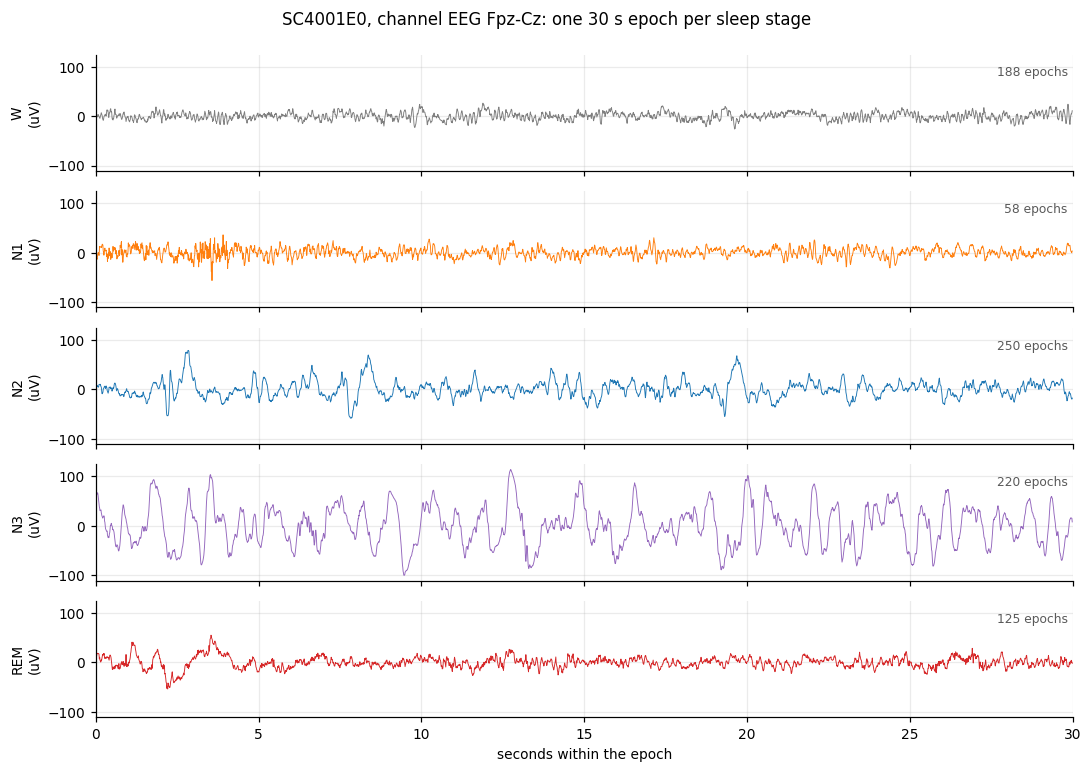

In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})
STAGE_COLOURS = {0: "tab:gray", 1: "tab:orange", 2: "tab:blue",
                 3: "tab:purple", 4: "tab:red"}

figure, axes = plt.subplots(5, 1, figsize=(10, 7), sharex=True, sharey=True)
seconds = np.arange(epochs.shape[-1]) / sampling_rate
for stage, axis in enumerate(axes):
    where = np.where(labels == stage)[0]
    if len(where) == 0:
        axis.set_visible(False)
        continue
    axis.plot(seconds, epochs[where[len(where) // 2], 0],   # a middle example, channel 0
              linewidth=0.6, color=STAGE_COLOURS[stage])
    axis.set_ylabel(f"{STAGE_NAMES[stage]}\n(uV)")
    axis.text(0.995, 0.90, f"{len(where)} epochs", transform=axis.transAxes,
              ha="right", va="top", fontsize=8, color="0.35")
axes[-1].set_xlabel("seconds within the epoch")
axes[0].set_xlim(0, EPOCH_SECONDS)
figure.suptitle(f"{example['recording_id']}, channel {EXAMPLE_CHANNELS[0]}: "
                f"one 30 s epoch per sleep stage", y=0.995)
figure.tight_layout()
plt.show()


## 3. Matching electrode names to each model

Every model was pretrained on its own electrode names and none agree. Sleep-EDF gives
`EEG Fpz-Cz` and `EEG Pz-Oz`; LaBraM wants `FPZ` and `PZ`, REVE wants single positions,
CBraMod its own labels. Getting this wrong crashes nothing — it feeds a model a channel it
has never seen, and the embeddings quietly get worse.

So the mapping is data, not code: `configs/channel_maps/<dataset>.yaml`, one file per
dataset, with a `per_model` block per model family.


In [9]:
import yaml   # ships with the conda/pip base in practice; part of pyyaml

channel_map_path = REPO_ROOT / "configs" / "channel_maps" / "sleep_edf_expanded.yaml"
channel_map = yaml.safe_load(channel_map_path.read_text())

print(f"{channel_map_path.relative_to(REPO_ROOT)}\n")
print(f"  channels available in the dataset : {channel_map['channels_available']}")
print(f"  channels the benchmark uses       : {channel_map['channels_used']}\n")

CHANNELS = list(channel_map["channels_used"])
PER_MODEL = channel_map["per_model"]

print("  translation per model family")
for family, mapping in sorted(PER_MODEL.items()):
    if isinstance(mapping, str):
        # A bare string is a directive rather than a mapping. "skip" means this
        # model cannot be evaluated on this dataset at all, usually because its
        # channel vocabulary has nothing in common with what the dataset records.
        print(f"    {family:18s} directive: {mapping}")
    else:
        rendered = ", ".join(f"{src} -> {dst}" for src, dst in mapping.items())
        print(f"    {family:18s} {rendered}")


def channels_for(family, channels=CHANNELS):
    """Dataset channel names translated into one model family's vocabulary."""
    mapping = PER_MODEL.get(family)
    if mapping is None:
        return list(channels)          # channel agnostic, pass the names through
    if isinstance(mapping, str):
        if mapping == "skip":
            raise ValueError(
                f"{channel_map['dataset']} marks {family!r} as 'skip': this model is "
                f"not evaluated on this dataset. Choose another model.")
        raise ValueError(f"Unrecognised directive {mapping!r} for {family!r}.")
    return [mapping.get(name, name) for name in channels]


print(f"\n  cbramod sees {channels_for('cbramod')} where the EDF says {CHANNELS}")
print(f"  moment sees  {channels_for('moment')}, unchanged, because a generic time "
      f"series\n               model has no electrode vocabulary to map onto")
skipped = [f for f, m in PER_MODEL.items() if m == "skip"]
if skipped:
    print(f"\n  marked 'skip' for this dataset: {', '.join(skipped)}")


configs/channel_maps/sleep_edf_expanded.yaml

  channels available in the dataset : ['EEG Fpz-Cz', 'EEG Pz-Oz']
  channels the benchmark uses       : ['EEG Fpz-Cz', 'EEG Pz-Oz']

  translation per model family
    biot               EEG Fpz-Cz -> FP1-F3, EEG Pz-Oz -> P3-O1
    cbramod            EEG Fpz-Cz -> Fpz-Cz, EEG Pz-Oz -> Pz-Oz
    chronos            EEG Fpz-Cz -> EEG Fpz-Cz, EEG Pz-Oz -> EEG Pz-Oz
    core_sleep         EEG Fpz-Cz -> EEG Fpz-Cz, EEG Pz-Oz -> EEG Pz-Oz
    eegpt              EEG Fpz-Cz -> FPZ, EEG Pz-Oz -> PZ
    labram             EEG Fpz-Cz -> FPZ, EEG Pz-Oz -> PZ
    lagllama           EEG Fpz-Cz -> EEG Fpz-Cz, EEG Pz-Oz -> EEG Pz-Oz
    moirai             EEG Fpz-Cz -> EEG Fpz-Cz, EEG Pz-Oz -> EEG Pz-Oz
    moment             EEG Fpz-Cz -> EEG Fpz-Cz, EEG Pz-Oz -> EEG Pz-Oz
    neurogpt           EEG Fpz-Cz -> FZ, EEG Pz-Oz -> PZ
    neurolm            EEG Fpz-Cz -> FPZ, EEG Pz-Oz -> PZ
    neurorvq           EEG Fpz-Cz -> Fpz, EEG Pz-Oz -> Pz
    reve     

## 4. Choosing models

The paper's argument needs three kinds of model:

* **EEG foundation models**, pretrained on large EEG corpora.
* **Generic time-series models**, never trained on EEG. If these keep pace, the claim that
  EEG pretraining is solved does not hold.
* **An untrained control** — same architecture, random weights. This separates "the
  architecture suits the task" from "the pretraining helped".

Most checkpoints live in `artifacts/`, which is not distributed. The cell below sorts the
registry into what you can and cannot run here, so the limit is explicit rather than a
stack trace later.


In [10]:
from benchmarking_helpers import checkpoint_registry

registry = checkpoint_registry()
by_id = registry if isinstance(registry, dict) else {c.identifier: c for c in registry}


def availability(spec):
    """Classify how a checkpoint's weights are obtained."""
    path = getattr(spec, "checkpoint_path", None)
    if not path:
        return "no weights", "random initialisation"
    text = str(path)
    if text.startswith("artifacts") or text.startswith("/"):
        return "needs artifacts", text
    if (REPO_ROOT / text).exists():
        return "in repository", text
    return "downloads", text


runnable, blocked = [], []
for identifier, spec in sorted(by_id.items()):
    kind, detail = availability(spec)
    (blocked if kind == "needs artifacts" else runnable).append((identifier, kind, detail))

print(f"Runnable without artifacts/ ({len(runnable)} checkpoints):\n")
for identifier, kind, detail in runnable:
    print(f"  {identifier:28s} {kind:15s} {detail}")
print(f"\nOut of reach here ({len(blocked)} checkpoints need artifacts/):")
print("  " + ", ".join(i for i, _, _ in blocked[:10]) + ", ...")


Runnable without artifacts/ (14 checkpoints):

  brain_age_cnn_v2_pretrained  no weights      random initialisation
  cbramod_pretrained           downloads       braindecode/cbramod-pretrained
  cbramod_random_init          no weights      random initialisation
  chronos_t5_base              downloads       amazon/chronos-t5-base
  chronos_t5_large             downloads       amazon/chronos-t5-large
  chronos_t5_small             downloads       amazon/chronos-t5-small
  chronos_t5_tiny              downloads       amazon/chronos-t5-tiny
  deepsoz_hem_pretrained       in repository   src/extensions/models/backbones/third_party/deepsoz_hem/deepsoz_fold4.pth_4.tar
  moirai_base                  downloads       Salesforce/moirai-1.1-R-base
  moirai_large                 downloads       Salesforce/moirai-1.1-R-large
  moirai_small                 downloads       Salesforce/moirai-1.1-R-small
  moment_base                  downloads       AutonLab/MOMENT-1-base
  moment_large              

From that list: CBraMod as the EEG foundation model, MOMENT and Chronos as the generic
ones, CBraMod with random weights as the control.

Two gaps follow from having no `artifacts/`: no supervised sleep baseline (CoRe-Sleep,
SleePyCo and SleepTransformer all need local weights), and no REVE, NeuroLM, LaBraM, BIOT
or EEGPT. CBraMod is the one EEG foundation model in the paper whose weights come from
Hugging Face.

The cell also prints what each model expects as input, because they disagree and it
changes preprocessing.


In [11]:
import torch

MODELS = {
    "cbramod_pretrained":  ("cbramod", "CBraModBackbone", "EEG foundation model"),
    "cbramod_random_init": ("cbramod", "CBraModBackbone", "untrained control"),
    "moment_small":        ("moment", "MomentBackbone", "generic time series model"),
    "chronos_t5_small":    ("chronos", "ChronosBackbone", "generic time series model"),
}

# Task specific supervised baselines. These need weights under artifacts/, so they
# are optional: if the files are absent the notebook drops them and says so rather
# than failing. Both also need a companion file, listed here alongside.
SUPERVISED = {
    "core_sleep_shhs_fold0": (
        "core_sleep", "CoreSleepBackbone", "supervised sleep baseline",
        ["artifacts/models/shhs/core_sleep_pretrained_fold0.pth.tar",
         "artifacts/models/shhs/stft_norm_eeg.npz"]),
    "seizure_transformer_pretrained": (
        "seizure_transformer", "SeizureTransformerBackbone", "supervised seizure baseline",
        ["artifacts/models/supervised/seizure_transformer/model.pth"]),
}

# CBraMod's pretraining window. A 30 s sleep epoch is embedded as three of these.
CBRAMOD_WINDOW_SECONDS = 10.0


LFS_MAGIC = b"version https://git-lfs"


def weights_present(identifier):
    """True when every file a supervised baseline needs is on disk and usable.

    Size alone is not a reliable test: the CoRe-Sleep normalisation stats are a
    legitimate 2.5 kB npz. What matters is whether the file is a Git LFS pointer
    stub standing in for content that was never fetched, which is detectable from
    its first bytes.
    """
    for relative in SUPERVISED[identifier][3]:
        path = REPO_ROOT / relative
        if not path.exists():
            return False, f"missing {relative}"
        with open(path, "rb") as handle:
            if handle.read(len(LFS_MAGIC)) == LFS_MAGIC:
                return False, f"{relative} is an unfetched Git LFS pointer"
    return True, "available"


AVAILABLE_SUPERVISED = {}
for identifier in SUPERVISED:
    ok, why = weights_present(identifier)
    if ok:
        AVAILABLE_SUPERVISED[identifier] = SUPERVISED[identifier][:3]
    print(f"  supervised  {identifier:32s} {why}")

# Everything the notebook can instantiate, keyed the same way.
ALL_MODELS = {**MODELS, **{k: v[:3] for k, v in SUPERVISED.items()}}

print()
for identifier, (_, _, role) in {**MODELS, **AVAILABLE_SUPERVISED}.items():
    spec = by_id[identifier]
    kind, detail = availability(spec)
    print(f"  {identifier:32s} {role:26s} dim={getattr(spec, 'embedding_dim', '?'):<5} "
          f"{kind}")


def load_backbone(identifier):
    """Instantiate a backbone. Weights download on the first call and are then cached."""
    module_name, class_name, _ = ALL_MODELS[identifier]
    module = importlib.import_module(
        f"extensions.models.backbones.{module_name}")
    return getattr(module, class_name)(by_id[identifier])


print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")


  supervised  core_sleep_shhs_fold0            missing artifacts/models/shhs/core_sleep_pretrained_fold0.pth.tar
  supervised  seizure_transformer_pretrained   missing artifacts/models/supervised/seizure_transformer/model.pth

  cbramod_pretrained               EEG foundation model       dim=200   downloads
  cbramod_random_init              untrained control          dim=200   no weights
  moment_small                     generic time series model  dim=512   downloads
  chronos_t5_small                 generic time series model  dim=512   downloads

Device: cuda


## 5. Extracting embeddings

The protocol is frozen-backbone linear probing: run each epoch through the model once,
keep the vector, never update the weights. That isolates representation quality from
training tricks, and the expensive part happens once per model.

Each batch carries the signal plus the metadata the model needs to read it — models use
`sampling_rate` to resample, `unit` to normalise, and `channels` to look up per-electrode
embeddings, which is where section 3's mapping is consumed.

One wrinkle: CBraMod works on 10 second windows, not 30 second epochs. Here each epoch is
split into three windows, embedded, and concatenated. The harness instead applies the
per-checkpoint `runtime_overrides`, so CBraMod numbers here will not match the paper's.


In [12]:
def make_batch(epoch_array, family, sampling_rate):
    """Wrap epochs as the batch dictionary a backbone expects."""
    tensor = torch.from_numpy(np.ascontiguousarray(epoch_array)).float()
    n = tensor.shape[0]
    meta = [{
        "dataset": "sleep_edf_expanded",
        "sampling_rate": float(sampling_rate),
        "unit": "uV",
        "channels": channels_for(family),
        "epoch_seconds": tensor.shape[-1] / sampling_rate,
    } for _ in range(n)]
    return {"signals": {"eeg": tensor},
            "label": torch.zeros(n, dtype=torch.long),   # unused, required by the contract
            "meta": meta}


def embed(backbone, family, epoch_array, sampling_rate, batch_size=64,
          window_seconds=None):
    """Embed epochs, optionally in fixed sub windows that are then concatenated."""
    if window_seconds is not None:
        samples = int(round(window_seconds * sampling_rate))
        n_windows = epoch_array.shape[-1] // samples
        if n_windows < 1:
            raise ValueError(f"Epoch is shorter than the model's {window_seconds:g} s window.")
        pieces = [embed(backbone, family,
                        epoch_array[..., i * samples:(i + 1) * samples],
                        sampling_rate, batch_size)
                  for i in range(n_windows)]
        return np.concatenate(pieces, axis=1)

    out = []
    for start in range(0, epoch_array.shape[0], batch_size):
        chunk = epoch_array[start:start + batch_size]
        out.append(np.asarray(backbone.extract_embeddings(
            make_batch(chunk, family, sampling_rate))))
    return np.concatenate(out, axis=0) if out else np.empty((0, 0), np.float32)


# Sanity check on the single recording loaded in section 2, before the full pass.
probe_backbone = load_backbone("cbramod_pretrained")
sample = embed(probe_backbone, "cbramod", epochs[:8], sampling_rate,
               window_seconds=CBRAMOD_WINDOW_SECONDS)
print(f"8 epochs of {EPOCH_SECONDS:g} s at {sampling_rate:g} Hz")
print(f"  input  {epochs[:8].shape}")
print(f"  output {sample.shape}   "
      f"({int(EPOCH_SECONDS // CBRAMOD_WINDOW_SECONDS)} windows x "
      f"{sample.shape[1] // int(EPOCH_SECONDS // CBRAMOD_WINDOW_SECONDS)} dims)")
print(f"  finite {np.isfinite(sample).all()}")


8 epochs of 30 s at 100 Hz
  input  (8, 2, 3000)
  output (8, 600)   (3 windows x 200 dims)
  finite True


Now the full pass over fold 0.

**This is the slow cell.** Fold 0's three splits together cover the whole cohort, so every
subject must be embedded. `SUBJECT_LIMIT` keeps the first N of each split so you can walk
the notebook end to end first; any value but `None` makes the numbers illustrative.


In [13]:
import time

# Number of subjects kept per split. None means the whole of fold 0.
# Override without editing the notebook: export NEUROATLAS_SUBJECT_LIMIT=none
_limit = os.environ.get("NEUROATLAS_SUBJECT_LIMIT", "6").strip().lower()
SUBJECT_LIMIT = None if _limit in ("none", "0", "all", "") else int(_limit)
MODEL_FOR_WALKTHROUGH = "cbramod_pretrained"


AVAILABLE_SUBJECTS = {r["subject_id"] for r in recordings}


def subjects_in(split_name, split=sleep_split, limit=SUBJECT_LIMIT):
    """Subjects of one split, in manifest order, restricted to what is on disk.

    The manifest covers 197 recordings across the Cassette and Telemetry subsets.
    If you downloaded only one subset, or are working from a partial copy, the
    missing subjects are dropped here rather than silently producing an empty
    split further down.
    """
    ordered, seen = [], set()
    for recording_id in getattr(split, split_name):
        subject = recording_to_subject(recording_id)
        if subject in seen or subject not in AVAILABLE_SUBJECTS:
            continue
        seen.add(subject)
        ordered.append(subject)
    return ordered[:limit] if limit else ordered


wanted = {name: set(subjects_in(name)) for name in ("train", "val", "test")}
selected = [r for r in recordings
            if any(r["subject_id"] in group for group in wanted.values())]

print(f"Subjects per split: "
      + ", ".join(f"{k}={len(v)}" for k, v in wanted.items())
      + f"  ({len(selected)} recordings)")
if SUBJECT_LIMIT:
    print(f"SUBJECT_LIMIT={SUBJECT_LIMIT}, so this is a demonstration slice, "
          f"not the full fold.\n")

backbone = load_backbone(MODEL_FOR_WALKTHROUGH)
family = MODELS[MODEL_FOR_WALKTHROUGH][0]

features, stage_labels, subject_of_epoch, recording_of_epoch = [], [], [], []
per_recording = {}
started = time.time()

for i, recording in enumerate(selected, 1):
    epoch_array, epoch_labels, rate = load_epochs(recording, channels=CHANNELS)
    if epoch_array.shape[0] == 0:
        print(f"  [{i}/{len(selected)}] {recording['recording_id']} has no scored epochs")
        continue
    vectors = embed(backbone, family, epoch_array, rate,
                    window_seconds=CBRAMOD_WINDOW_SECONDS)
    features.append(vectors)
    stage_labels.append(epoch_labels)
    subject_of_epoch += [recording["subject_id"]] * len(epoch_labels)
    recording_of_epoch += [recording["recording_id"]] * len(epoch_labels)
    per_recording[recording["recording_id"]] = {
        "subject_id": recording["subject_id"], "n_epochs": len(epoch_labels)}
    print(f"  [{i}/{len(selected)}] {recording['recording_id']}  "
          f"{len(epoch_labels):5d} epochs -> {vectors.shape}")

X = np.concatenate(features).astype(np.float32)
y = np.concatenate(stage_labels)
subject_of_epoch = np.array(subject_of_epoch)
recording_of_epoch = np.array(recording_of_epoch)

print(f"\nEmbedding matrix {X.shape}, labels {y.shape}, "
      f"{len(per_recording)} recordings, {time.time() - started:.0f} s")


Subjects per split: train=6, val=6, test=6  (36 recordings)
SUBJECT_LIMIT=6, so this is a demonstration slice, not the full fold.



  [1/36] SC4001E0    841 epochs -> (841, 600)


  [2/36] SC4002E0   1127 epochs -> (1127, 600)


  [3/36] SC4011E0   1103 epochs -> (1103, 600)


  [4/36] SC4012E0   1186 epochs -> (1186, 600)


...

  [32/36] SC4222E0   1108 epochs -> (1108, 600)


  [33/36] SC4281G0   1127 epochs -> (1127, 600)


  [34/36] SC4282G0   1070 epochs -> (1070, 600)


  [35/36] SC4311E0   1054 epochs -> (1054, 600)


  [36/36] SC4312E0   1181 epochs -> (1181, 600)

Embedding matrix (37665, 600), labels (37665,), 36 recordings, 57 s


Do these vectors even contain what we are about to ask a linear model to find? Project
them onto their first two principal components and colour by true stage.

Clear structure is strong evidence the probe has something to work with. Overlap is weak
evidence against it — this keeps two directions out of 600.


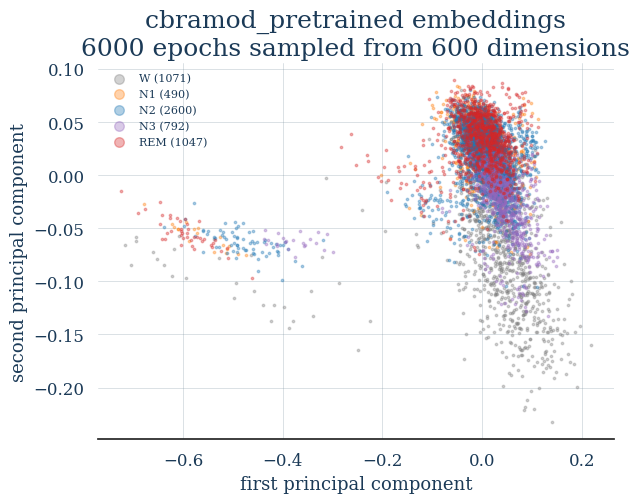

In [14]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(SEED)
sample = rng.choice(len(X), size=min(6000, len(X)), replace=False)
centred = X[sample] - X[sample].mean(axis=0)
projected = PCA(n_components=2, random_state=SEED).fit_transform(centred)

figure, axis = plt.subplots(figsize=(6.4, 5.2))
for stage in range(5):
    mask = y[sample] == stage
    if mask.sum():
        axis.scatter(projected[mask, 0], projected[mask, 1], s=3, alpha=0.35,
                     color=STAGE_COLOURS[stage],
                     label=f"{STAGE_NAMES[stage]} ({mask.sum()})")
axis.set_xlabel("first principal component")
axis.set_ylabel("second principal component")
axis.set_title(f"{MODEL_FOR_WALKTHROUGH} embeddings\n{len(sample)} epochs sampled "
               f"from {X.shape[1]} dimensions")
axis.legend(markerscale=4, frameon=False, fontsize=8)
figure.tight_layout()
plt.show()


## 6. Fitting the probe

Multinomial logistic regression on the frozen embeddings. Three details matter more than
the choice of classifier:

1. **Split by subject, never by epoch.** Random epoch splits put neighbouring 30 second
   windows from the same night on both sides. They are nearly identical, so accuracy
   inflates enormously and measures nothing.
2. **Standardisation is fitted on train only.** Otherwise test statistics leak in.
3. **Regularisation is chosen on validation.** Test is touched exactly once, at the end.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

in_split = {name: np.isin(subject_of_epoch, sorted(group))
            for name, group in wanted.items()}
for name, mask in in_split.items():
    print(f"  {name:5s} {mask.sum():6d} epochs from "
          f"{len(set(subject_of_epoch[mask]))} subjects")

overlap = set(subject_of_epoch[in_split["train"]]) & set(subject_of_epoch[in_split["test"]])
assert not overlap, f"Subject leakage between train and test: {overlap}"
print("\n  no subject appears in both train and test")

scaler = StandardScaler().fit(X[in_split["train"]])
Xs = {name: scaler.transform(X[mask]) for name, mask in in_split.items()}
ys = {name: y[mask] for name, mask in in_split.items()}

from sklearn.metrics import cohen_kappa_score

best = None
print("\n  selecting regularisation strength on validation")
for C in (0.001, 0.01, 0.1, 1.0):
    model = LogisticRegression(C=C, max_iter=2000, random_state=SEED)
    model.fit(Xs["train"], ys["train"])
    kappa = cohen_kappa_score(ys["val"], model.predict(Xs["val"]))
    print(f"    C={C:<7g} validation kappa {kappa:.4f}")
    if best is None or kappa > best[0]:
        best = (kappa, C, model)

val_kappa, best_C, probe = best
print(f"\n  chosen C={best_C:g} (validation kappa {val_kappa:.4f})")


  train  11963 epochs from 6 subjects
  val    12983 epochs from 6 subjects
  test   12719 epochs from 6 subjects

  no subject appears in both train and test

  selecting regularisation strength on validation


    C=0.001   validation kappa 0.6261


    C=0.01    validation kappa 0.6274


    C=0.1     validation kappa 0.6084


    C=1       validation kappa 0.5957

  chosen C=0.01 (validation kappa 0.6274)


### The test set, once

`predicted` is the only place test labels meet a prediction. All of section 7 comes from it.


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

predicted = probe.predict(Xs["test"])
truth = ys["test"]

accuracy = accuracy_score(truth, predicted)
macro_f1 = f1_score(truth, predicted, average="macro")
kappa = cohen_kappa_score(truth, predicted)

print(f"Sleep staging on {len(truth)} held out epochs "
      f"from {len(set(subject_of_epoch[in_split['test']]))} subjects\n")
print(f"  accuracy        {accuracy:.4f}")
print(f"  macro F1        {macro_f1:.4f}")
print(f"  Cohen's kappa   {kappa:.4f}\n")
present = sorted(set(truth) | set(predicted))
print(classification_report(truth, predicted, labels=present,
                            target_names=[STAGE_NAMES[i] for i in present],
                            digits=3, zero_division=0))
print("Confusion matrix, rows are true stages and columns predicted:\n")
print("        " + "".join(f"{STAGE_NAMES[i]:>7s}" for i in present))
for row, i in zip(confusion_matrix(truth, predicted, labels=present), present):
    print(f"  {STAGE_NAMES[i]:5s} " + "".join(f"{v:7d}" for v in row))


Sleep staging on 12719 held out epochs from 6 subjects

  accuracy        0.6397
  macro F1        0.6007
  Cohen's kappa   0.5199

              precision    recall  f1-score   support

           W      0.510     0.662     0.576      2146
          N1      0.326     0.277     0.299      1262
          N2      0.840     0.673     0.747      5421
          N3      0.922     0.756     0.831      1585
         REM      0.472     0.659     0.550      2305

    accuracy                          0.640     12719
   macro avg      0.614     0.605     0.601     12719
weighted avg      0.677     0.640     0.649     12719

Confusion matrix, rows are true stages and columns predicted:

              W     N1     N2     N3    REM
  W        1421    205     58     18    444
  N1        224    349    164      2    523
  N2        724    236   3648     82    731
  N3        130      1    254   1198      2
  REM       287    281    217      0   1520


Easier to read as a picture — each row normalised, so it shows where one true stage's
epochs ended up. A perfect model is a bright diagonal.

Follow the N1 row. The errors scatter into Wake, N2 and REM rather than into one
neighbour, which is the signature of a stage the representation does not separate at all —
different from a model that merely confuses two adjacent stages.


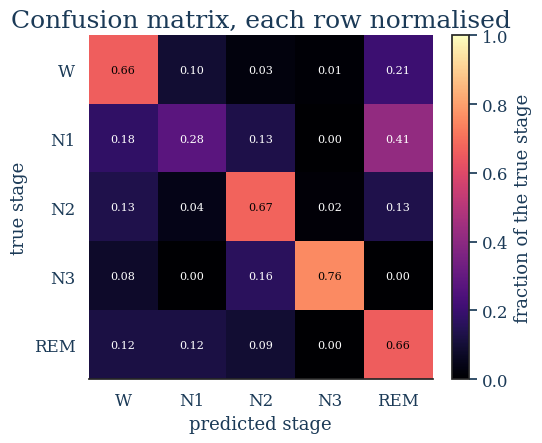

In [17]:
matrix = confusion_matrix(truth, predicted, labels=present).astype(float)
normalised = matrix / matrix.sum(axis=1, keepdims=True).clip(min=1)

figure, axis = plt.subplots(figsize=(5.4, 4.6))
image = axis.imshow(normalised, cmap="magma", vmin=0, vmax=1)
axis.set_xticks(range(len(present)), [STAGE_NAMES[i] for i in present])
axis.set_yticks(range(len(present)), [STAGE_NAMES[i] for i in present])
axis.set_xlabel("predicted stage")
axis.set_ylabel("true stage")
axis.set_title("Confusion matrix, each row normalised")
axis.grid(False)
for r in range(len(present)):
    for c in range(len(present)):
        axis.text(c, r, f"{normalised[r, c]:.2f}", ha="center", va="center", fontsize=8,
                  color="white" if normalised[r, c] < 0.6 else "black")
figure.colorbar(image, ax=axis, fraction=0.046, label="fraction of the true stage")
figure.tight_layout()
plt.show()


## 7. The numbers that matter

Per-epoch accuracy is where most sleep papers stop, and it is not the paper's main result.
A model can be accurate per epoch and still produce a hypnogram no clinician would accept,
because what matters clinically is properties of the *whole night* — how long the patient
slept, how fragmented it was, when REM arrived. Two models with equal accuracy can
disagree sharply on all three.

### 7a. Reconstruct the hypnogram

Predictions come back in extraction order, so regrouping by recording gives a hypnogram
directly.


In [18]:
test_recordings = recording_of_epoch[in_split["test"]]

hypnograms = {}
for recording_id in dict.fromkeys(test_recordings):     # preserves order
    mask = test_recordings == recording_id
    hypnograms[recording_id] = {"true": truth[mask], "predicted": predicted[mask]}

print(f"Reconstructed {len(hypnograms)} hypnograms from the test split:\n")
for recording_id, night in hypnograms.items():
    agreement = (night["true"] == night["predicted"]).mean()
    hours = len(night["true"]) * EPOCH_SECONDS / 3600
    print(f"  {recording_id}  {len(night['true']):5d} epochs "
          f"({hours:4.1f} h)  per epoch agreement {agreement:.3f}")


Reconstructed 12 hypnograms from the test split:

  SC4001E0    841 epochs ( 7.0 h)  per epoch agreement 0.781
  SC4002E0   1127 epochs ( 9.4 h)  per epoch agreement 0.797
  SC4041E0   1235 epochs (10.3 h)  per epoch agreement 0.668
  SC4042E0   1200 epochs (10.0 h)  per epoch agreement 0.678
  SC4101E0   1104 epochs ( 9.2 h)  per epoch agreement 0.727
  SC4102E0   1092 epochs ( 9.1 h)  per epoch agreement 0.778
  SC4121E0   1052 epochs ( 8.8 h)  per epoch agreement 0.746
  SC4122E0    977 epochs ( 8.1 h)  per epoch agreement 0.579
  SC4181E0    964 epochs ( 8.0 h)  per epoch agreement 0.770
  SC4182E0    920 epochs ( 7.7 h)  per epoch agreement 0.724
  SC4221E0   1099 epochs ( 9.2 h)  per epoch agreement 0.272
  SC4222E0   1108 epochs ( 9.2 h)  per epoch agreement 0.208


Read a hypnogram as a staircase against time, Wake at the top, N3 at the bottom, REM
highlighted. Truth above prediction makes the failure modes obvious in a way a confusion
matrix does not: look for REM misread as N2, and for extra transitions fragmenting the
night.


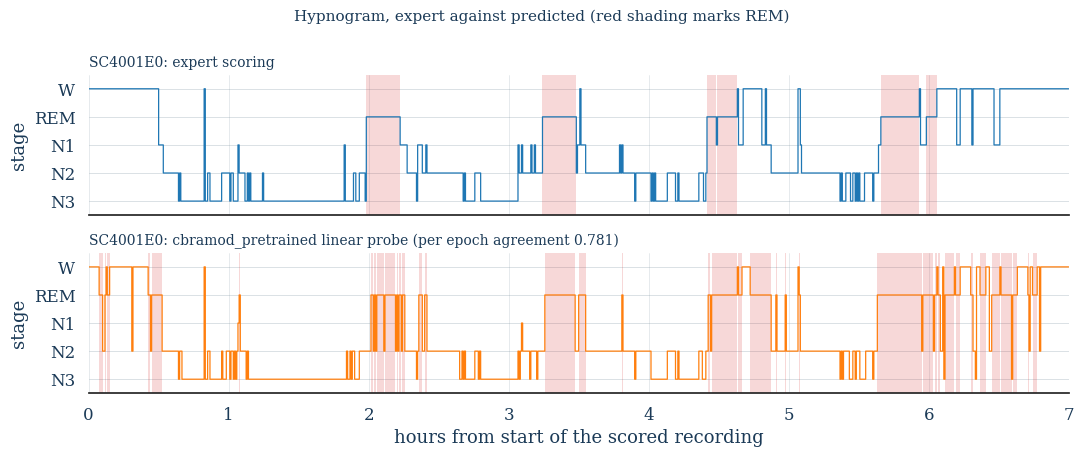

In [19]:
import matplotlib.pyplot as plt

# Plot order puts deep sleep at the bottom and REM just below Wake, the usual convention.
PLOT_ROW = {0: 4, 4: 3, 1: 2, 2: 1, 3: 0}          # stage -> row
PLOT_TICKS = ["N3", "N2", "N1", "REM", "W"]

def draw_hypnogram(axis, stages, title, colour):
    rows = np.array([PLOT_ROW[int(s)] for s in stages])
    hours = np.arange(len(stages)) * EPOCH_SECONDS / 3600
    axis.step(hours, rows, where="post", linewidth=0.9, color=colour)
    rem = np.where(stages == 4)[0]
    for i in rem:                                   # highlight REM bouts
        axis.axvspan(i * EPOCH_SECONDS / 3600, (i + 1) * EPOCH_SECONDS / 3600,
                     color="tab:red", alpha=0.18, linewidth=0)
    axis.set_yticks(range(5), PLOT_TICKS)
    axis.set_ylim(-0.5, 4.5)
    axis.set_xlim(0, hours[-1] if len(hours) else 1)
    axis.set_ylabel("stage")
    axis.set_title(title, loc="left", fontsize=10)
    axis.grid(axis="x", alpha=0.25, linewidth=0.5)

shown = next(iter(hypnograms))
night = hypnograms[shown]

figure, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
draw_hypnogram(axes[0], night["true"], f"{shown}: expert scoring", "tab:blue")
draw_hypnogram(axes[1], night["predicted"],
               f"{shown}: {MODEL_FOR_WALKTHROUGH} linear probe "
               f"(per epoch agreement {(night['true'] == night['predicted']).mean():.3f})",
               "tab:orange")
axes[1].set_xlabel("hours from start of the scored recording")
figure.suptitle("Hypnogram, expert against predicted (red shading marks REM)",
                fontsize=11, y=0.99)
figure.tight_layout()
plt.show()


### 7b. Clinical features

What a sleep report actually contains, written out rather than imported so you can see
what is measured:

* **TST** — time in any stage other than Wake.
* **Sleep efficiency** — TST over the scored recording.
* **WASO** — Wake after the first sleep epoch.
* **REM latency** — sleep onset to first REM.
* **Awakenings** — transitions from sleep into Wake.

What matters is the *error* against the expert hypnogram, not the value. That error is the
clinical readout, and it reorders model rankings relative to plain accuracy. The harness
computes 34 such features; see `entrypoints/hypnogram.py`.


In [20]:
import pandas as pd


def hypnogram_features(stages, epoch_seconds=EPOCH_SECONDS):
    """Clinical summary of one night. Times are in minutes."""
    stages = np.asarray(stages)
    per_epoch = epoch_seconds / 60.0
    asleep = stages != 0
    total = len(stages) * per_epoch

    if not asleep.any():
        return {"TST": 0.0, "SleepEff": 0.0, "WASO": 0.0,
                "RemLatency": np.nan, "Awakenings": 0}

    onset = int(np.argmax(asleep))
    after_onset = stages[onset:]
    rem = np.where(after_onset == 4)[0]
    wake_transitions = int(np.sum((stages[:-1] != 0) & (stages[1:] == 0)))
    return {
        "TST": float(asleep.sum() * per_epoch),
        "SleepEff": float(100.0 * asleep.sum() * per_epoch / total),
        "WASO": float((after_onset == 0).sum() * per_epoch),
        "RemLatency": float(rem[0] * per_epoch) if len(rem) else np.nan,
        "Awakenings": wake_transitions,
    }


rows = []
for recording_id, night in hypnograms.items():
    expert = hypnogram_features(night["true"])
    model = hypnogram_features(night["predicted"])
    for feature in expert:
        rows.append({"recording_id": recording_id, "feature": feature,
                     "expert": expert[feature], "predicted": model[feature],
                     "error": model[feature] - expert[feature]})

features_frame = pd.DataFrame(rows)
wide = features_frame.pivot(index="recording_id", columns="feature",
                            values=["expert", "predicted"])
print("Per night values, expert against predicted:\n")
print(wide.round(1).to_string())

summary = (features_frame.groupby("feature")
           .agg(mean_absolute_error=("error", lambda s: s.abs().mean()),
                bias=("error", "mean"))
           .reindex(["TST", "SleepEff", "WASO", "RemLatency", "Awakenings"]))
print("\nAgreement across the test nights "
      "(minutes, except SleepEff in percent and Awakenings as a count):\n")
print(summary.round(2).to_string())
print("\nBias is signed, so it tells you the direction of the systematic error: "
      "a positive\nWASO bias means the model reports the patient as more awake than the "
      "expert did.")
print("\nWatch for features where the absolute value of the bias equals the mean absolute")
print("error. That means the error points the same way in every single night, which is a")
print("systematic artefact rather than noise. REM latency and awakening count both do")
print("this, and for the same reason: they are defined by a first occurrence or by")
print("counting transitions, so a single isolated misclassified epoch moves them a long")
print("way. One spurious REM epoch in the first minutes sets REM latency to nearly zero")
print("however good the rest of the night is. Clinical scoring rules avoid this by")
print("requiring a minimum bout length; the naive definitions above deliberately do not,")
print("because the fragility is the point. A model can look respectable per epoch and")
print("still be unusable for the quantity a sleep report actually contains.")


Per night values, expert against predicted:

                 expert                                    predicted                                  
feature      Awakenings RemLatency SleepEff    TST   WASO Awakenings RemLatency SleepEff    TST   WASO
recording_id                                                                                          
SC4001E0           11.0       89.0     77.6  326.5   64.0       18.0        0.0     87.0  366.0   50.0
SC4002E0           22.0       65.5     83.8  472.0   61.5       28.0        3.5     88.6  499.5   40.5
SC4041E0           29.0       72.0     83.8  517.5   70.0       43.0       16.5     88.1  544.0   73.5
SC4042E0           15.0      105.0     84.6  507.5   62.5       40.0        9.0     84.1  504.5   75.0
SC4101E0           13.0       83.5     86.0  474.5   47.5       28.0        0.0     91.3  504.0   48.0
SC4102E0           11.0       62.0     86.8  474.0   42.0       16.0        0.0     91.3  498.5   47.5
SC4121E0           18.0     

### 7c. Brain age

The same embeddings support a second task with no further extraction — which is the point
of caching them. Predict chronological age from the night's EEG, then report the **brain
age gap**: predicted minus true. The gap is the clinical readout, because a consistently
positive one is what "this brain looks older than it is" means quantitatively.

Two differences from staging: ages are per recording, so epoch embeddings are pooled per
night; and the target is continuous, so the probe is ridge regression and the metric is
mean absolute error in years.


In [21]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


def load_ages(root):
    """Read both subject tables into {subject_id: age}, keyed like recording ids.

    The two ship in different shapes: SC-subjects.xls is one row per recording
    with tidy column names, ST-subjects.xls is one row per subject under a
    two-line header.
    """
    ages = {}
    cassette = pd.read_excel(Path(root) / "SC-subjects.xls")
    for _, row in cassette.iterrows():
        ages.setdefault(f"SC4{int(row['subject']):02d}", float(row["age"]))

    telemetry = pd.read_excel(Path(root) / "ST-subjects.xls", header=1)
    for _, row in telemetry.iterrows():
        try:
            nr, age = int(row["Nr"]), float(row["Age"])
        except (TypeError, ValueError, KeyError):
            continue                      # the stray header/blank rows
        ages.setdefault(f"ST7{nr:02d}", age)
    return ages


ages = load_ages(SLEEPEDF_ROOT)

# One pooled vector per recording. Mean over epochs is what the harness uses by default.
pooled, pooled_age, pooled_subject = [], [], []
for recording_id in dict.fromkeys(recording_of_epoch):
    subject = per_recording[recording_id]["subject_id"]
    if subject not in ages:
        continue
    pooled.append(X[recording_of_epoch == recording_id].mean(axis=0))
    pooled_age.append(ages[subject])
    pooled_subject.append(subject)

pooled = np.vstack(pooled)
pooled_age = np.asarray(pooled_age, dtype=np.float64)
pooled_subject = np.asarray(pooled_subject)

is_train = np.isin(pooled_subject, sorted(wanted["train"] | wanted["val"]))
is_test = np.isin(pooled_subject, sorted(wanted["test"]))
print(f"Pooled to {pooled.shape[0]} recordings, {pooled.shape[1]} dimensions")
print(f"  train and validation {is_train.sum()} recordings")
print(f"  test                 {is_test.sum()} recordings")
print(f"  age range            {pooled_age.min():.0f} to {pooled_age.max():.0f} years\n")

age_scaler = StandardScaler().fit(pooled[is_train])
regressor = Ridge(alpha=10.0, random_state=SEED).fit(
    age_scaler.transform(pooled[is_train]), pooled_age[is_train])

predicted_age = regressor.predict(age_scaler.transform(pooled[is_test]))
true_age = pooled_age[is_test]
gap = predicted_age - true_age

print(f"  mean absolute error   {mean_absolute_error(true_age, predicted_age):.2f} years")
print(f"  r2                    {r2_score(true_age, predicted_age):.3f}")
print(f"  brain age gap         {gap.mean():+.2f} years (sd {gap.std():.2f})\n")
for subject, actual, estimate in zip(pooled_subject[is_test], true_age, predicted_age):
    print(f"    {subject}  true {actual:5.1f}  predicted {estimate:5.1f}  "
          f"gap {estimate - actual:+5.1f}")


Pooled to 36 recordings, 600 dimensions
  train and validation 24 recordings
  test                 12 recordings
  age range            25 to 56 years

  mean absolute error   7.71 years
  r2                    0.113
  brain age gap         +2.05 years (sd 9.58)

    SC400  true  33.0  predicted  31.5  gap  -1.5
    SC400  true  33.0  predicted  22.8  gap -10.2
    SC404  true  34.0  predicted  33.5  gap  -0.5
    SC404  true  34.0  predicted  36.2  gap  +2.2
    SC410  true  26.0  predicted  38.1  gap +12.1
    SC410  true  26.0  predicted  29.9  gap  +3.9
    SC412  true  26.0  predicted  40.2  gap +14.2
    SC412  true  26.0  predicted  40.2  gap +14.2
    SC418  true  28.0  predicted  25.1  gap  -2.9
    SC418  true  28.0  predicted  29.6  gap  +1.6
    SC422  true  56.0  predicted  37.1  gap -18.9
    SC422  true  56.0  predicted  66.4  gap +10.4


Judge brain age from a scatter of predicted against true. The dashed diagonal is perfect;
each vertical line is that night's gap.

The failure mode is a flat cloud — predictions hugging the training mean whatever the true
age. That is what a regressor does when the features carry no age information, and it
still gives an unremarkable-looking MAE. The dotted line marks the training mean: if the
points track it more closely than the diagonal, the model learned the cohort average and
nothing else, and the negative r2 is saying so.


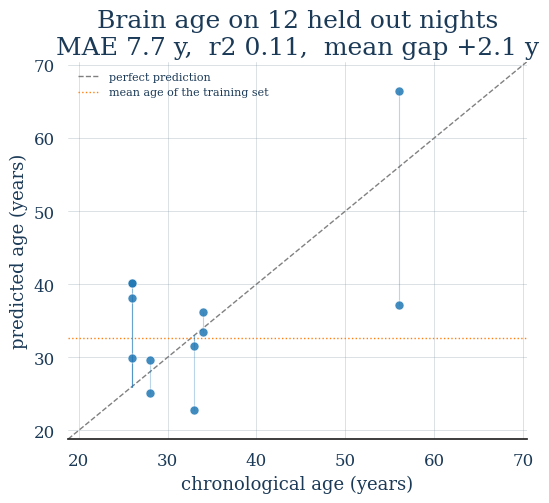

In [22]:
figure, axis = plt.subplots(figsize=(5.6, 5.2))
limits = [min(true_age.min(), predicted_age.min()) - 4,
          max(true_age.max(), predicted_age.max()) + 4]
axis.plot(limits, limits, color="0.5", linestyle="--", linewidth=1,
          label="perfect prediction")
axis.axhline(pooled_age[is_train].mean(), color="tab:orange", linewidth=1, linestyle=":",
             label="mean age of the training set")
for actual, estimate in zip(true_age, predicted_age):
    axis.plot([actual, actual], [actual, estimate], color="tab:blue", alpha=0.3,
              linewidth=0.8)
axis.scatter(true_age, predicted_age, s=42, alpha=0.85, color="tab:blue",
             edgecolor="white", linewidth=0.5, zorder=3)
axis.set_xlim(limits)
axis.set_ylim(limits)
axis.set_xlabel("chronological age (years)")
axis.set_ylabel("predicted age (years)")
axis.set_title(f"Brain age on {int(is_test.sum())} held out nights\n"
               f"MAE {mean_absolute_error(true_age, predicted_age):.1f} y,  "
               f"r2 {r2_score(true_age, predicted_age):.2f},  "
               f"mean gap {gap.mean():+.1f} y")
axis.legend(frameon=False, fontsize=8, loc="upper left")
figure.tight_layout()
plt.show()


With a handful of subjects these statistics are noise, and ridge on few nights predicts
near the training mean. Treat the mechanics as the deliverable; set `SUBJECT_LIMIT` to
`None` for values worth interpreting.


### 7d. Seizure detection over whole recordings

Epilepsy is where window-level metrics mislead most. Seizures occupy well under one percent
of a recording, so a model that never predicts one scores above 99 percent accuracy.
Clinicians ask two different questions:

* **Did you catch it?** Any-overlap sensitivity — a seizure counts as detected if any part
  overlaps any positive prediction.
* **How often do you cry wolf?** False alarms per hour over the full recording. This is
  what decides whether a detector is usable.

Both are event-level, so predictions must be laid back along the timeline rather than
shuffled — which is why this section works on whole recordings.

CHB-MIT arrives as BIDS, and parsing it teaches nothing about the protocol, so the
repository's reader handles that one step. Everything after is explicit.


In [23]:
from extensions.datasets.adapters.chbmit import CHBMITBenchmarkDataModule

# Look for the BIDS tree itself, not just the download directory: a download that
# is still running, or was interrupted before unzipping, leaves the directory in
# place with no usable data in it.
BIDS_ROOT = CHBMIT_ROOT / "BIDS_CHB-MIT"
RUN_EPILEPSY = any(BIDS_ROOT.glob("sub-*")) if BIDS_ROOT.is_dir() else False

if not RUN_EPILEPSY:
    print(f"No CHB-MIT BIDS tree with sub-* directories under {BIDS_ROOT}.")
    print("Get it with:  python -m entrypoints.fetch --dataset chbmit")
    print("or unzip Zenodo record 10259996 (BIDS_CHB-MIT.zip) into $CHBMIT_ROOT.")
    print("That is about 22 GB, and it has to finish unzipping before this section runs.")
    print("Skipping section 7d.")
else:
    chbmit = CHBMITBenchmarkDataModule(
        backend="bids",
        bids_root=str(BIDS_ROOT),
        fold=FOLD,
        n_folds=5,
        window_s=CHBMIT_WINDOW_SECONDS,
        stride_s=CHBMIT_WINDOW_SECONDS,
        montage=CHBMIT_MONTAGE,
        label_mode="binary",
        overlap_threshold=0.0,
        balance="none",          # keep the true class ratio; see the note below
        batch_size=64,
        num_workers=2,
        folds_manifest="chbmit",
        strict_folds=True,
    )
    print("CHB-MIT module ready.")
    fold_source = str(chbmit.metadata.get("fold_source", ""))
    print(f"  split taken from {fold_source.replace(str(REPO_ROOT), '<repo>')}")
    print(f"  label space      {chbmit.metadata.get('canonical_label_space')}")
    print(f"  window           {chbmit.metadata.get('epoch_seconds')} s")


CHB-MIT module ready.
  split taken from <repo>/configs/cohorts/chbmit/folds.json
  label space      ['bckg', 'seiz']
  window           10.0 s


Two notes on the settings above. `balance="none"` keeps the real class ratio — the harness
default is a weighted sampler, which would distort false alarms per hour, since that only
means something against real elapsed time. `strict_folds=True` fails loudly if the
manifest names a subject your download lacks, because a silently partial cohort produces
numbers that look fine and compare to nothing.


In [24]:
def event_metrics(true_windows, predicted_windows,
                  window_seconds=CHBMIT_WINDOW_SECONDS):
    """Any overlap sensitivity and false alarms per hour, from window level labels.

    Both sequences are laid out along the recording timeline. Consecutive positive
    windows are merged into events before matching, which is what makes this event
    level rather than window level.
    """
    def to_events(binary):
        events, start = [], None
        for i, value in enumerate(list(binary) + [0]):
            if value and start is None:
                start = i
            elif not value and start is not None:
                events.append((start, i))
                start = None
        return events

    true_events = to_events(true_windows)
    predicted_events = to_events(predicted_windows)

    detected = sum(
        any(p_start < t_end and t_start < p_end
            for p_start, p_end in predicted_events)
        for t_start, t_end in true_events)
    false_alarms = sum(
        not any(t_start < p_end and p_start < t_end
                for t_start, t_end in true_events)
        for p_start, p_end in predicted_events)

    hours = len(true_windows) * window_seconds / 3600.0
    return {
        "n_seizures": len(true_events),
        "n_detected": detected,
        "any_overlap_sensitivity": detected / len(true_events) if true_events else np.nan,
        "n_false_alarms": false_alarms,
        "false_alarms_per_hour": false_alarms / hours if hours else np.nan,
        "hours": hours,
    }


# A worked example on a synthetic recording, so the accounting is verifiable by eye.
demo_true = np.array([0] * 20 + [1, 1, 1] + [0] * 30 + [1, 1] + [0] * 25)
demo_pred = np.array([0] * 21 + [1, 1] + [0] * 40 + [1] + [0] * 15)
print("Worked example on a synthetic recording:")
print(f"  true seizures at windows      {[(a, b) for a, b in [(20, 23), (53, 55)]]}")
for key, value in event_metrics(demo_true, demo_pred).items():
    print(f"  {key:26s} {value}")
print("\n  The first seizure overlaps a prediction, so it is detected. The second does "
      "not.\n  The stray prediction near the end overlaps no seizure, so it is one false "
      "alarm.")


Worked example on a synthetic recording:
  true seizures at windows      [(20, 23), (53, 55)]
  n_seizures                 2
  n_detected                 1
  any_overlap_sensitivity    0.5
  n_false_alarms             1
  false_alarms_per_hour      4.5
  hours                      0.2222222222222222

  The first seizure overlaps a prediction, so it is detected. The second does not.
  The stray prediction near the end overlaps no seizure, so it is one false alarm.


In [25]:
if RUN_EPILEPSY:
    seizure_backbone = load_backbone(MODEL_FOR_WALKTHROUGH)

    def embed_loader(loader, limit_batches=None):
        vectors, labels, groups = [], [], []
        for i, batch in enumerate(loader):
            if limit_batches and i >= limit_batches:
                break
            vectors.append(np.asarray(seizure_backbone.extract_embeddings(batch)))
            labels.append(np.asarray(batch["label"]).reshape(-1))
            groups += [m.get("recording_id", m.get("subject_id", "?"))
                       for m in batch["meta"]]
        return (np.concatenate(vectors), np.concatenate(labels), np.array(groups))

    # Batches of CHB-MIT windows kept per split. None means the whole of fold 0,
    # which is 353,824 windows and roughly two hours. Override the same way as
    # SUBJECT_LIMIT: export NEUROATLAS_LIMIT_BATCHES=none
    _batches = os.environ.get("NEUROATLAS_LIMIT_BATCHES", "40").strip().lower()
    LIMIT_BATCHES = None if _batches in ("none", "0", "all", "") else int(_batches)
    print("Embedding CHB-MIT windows. This is the slow part.\n")
    Xtr, ytr, _ = embed_loader(chbmit.train_dataloader(), LIMIT_BATCHES)
    Xte, yte, groups_te = embed_loader(chbmit.test_dataloader(), LIMIT_BATCHES)
    print(f"  train {Xtr.shape}, {int(ytr.sum())} seizure windows")
    print(f"  test  {Xte.shape}, {int(yte.sum())} seizure windows")

    seizure_scaler = StandardScaler().fit(Xtr)
    detector = LogisticRegression(max_iter=2000, class_weight="balanced",
                                  random_state=SEED)
    detector.fit(seizure_scaler.transform(Xtr), ytr)

    scores = detector.predict_proba(seizure_scaler.transform(Xte))[:, 1]
    print(f"\n  fitted on {len(ytr)} windows, scoring {len(yte)} test windows")
else:
    print("Section 7d skipped, CHB-MIT is not present.")


Embedding CHB-MIT windows. This is the slow part.



  train (2560, 200), 9 seizure windows
  test  (2560, 200), 27 seizure windows



  fitted on 2560 windows, scoring 2560 test windows


The decision threshold is the last free parameter and it trades the two metrics directly:
lower it to catch more seizures and pay in false alarms. A single operating point hides
that, so the sweep below shows the curve.


In [26]:
if RUN_EPILEPSY:
    from sklearn.metrics import average_precision_score, roc_auc_score

    print(f"  window level AUROC   {roc_auc_score(yte, scores):.4f}")
    print(f"  average precision    {average_precision_score(yte, scores):.4f}")
    print(f"  (positive rate in test: {100 * yte.mean():.3f} percent)\n")

    print(f"  {'threshold':>9s} {'sensitivity':>12s} {'FA/hour':>9s} {'detected':>9s}")
    sweep = []
    for threshold in (0.5, 0.7, 0.9, 0.95, 0.99):
        metrics = event_metrics(yte, (scores >= threshold).astype(int))
        sweep.append({"threshold": threshold, **metrics})
        print(f"  {threshold:9.2f} {metrics['any_overlap_sensitivity']:12.3f} "
              f"{metrics['false_alarms_per_hour']:9.2f} "
              f"{metrics['n_detected']:4d}/{metrics['n_seizures']:<4d}")

    headline = event_metrics(yte, (scores >= 0.5).astype(int))
    print(f"\n  At threshold 0.5, over {headline['hours']:.1f} h of recording:")
    print(f"    any overlap sensitivity  {headline['any_overlap_sensitivity']:.3f}")
    print(f"    false alarms per hour    {headline['false_alarms_per_hour']:.2f}")
    print("\n  These are the two epilepsy numbers the paper leads with. Note that a "
          "window level\n  accuracy would look excellent here regardless, which is the "
          "whole argument for\n  reporting event level metrics instead.")


  window level AUROC   0.9733
  average precision    0.3524
  (positive rate in test: 1.055 percent)

  threshold  sensitivity   FA/hour  detected
       0.50        1.000      2.95    4/4   
       0.70        1.000      2.39    4/4   
       0.90        1.000      1.97    4/4   
       0.95        0.750      1.55    3/4   
       0.99        0.750      0.84    3/4   

  At threshold 0.5, over 7.1 h of recording:
    any overlap sensitivity  1.000
    false alarms per hour    2.95

  These are the two epilepsy numbers the paper leads with. Note that a window level
  accuracy would look excellent here regardless, which is the whole argument for
  reporting event level metrics instead.


The top panel is the detector's score along the recording, with annotated seizures shaded —
this is what event-level means in practice. You are asking whether each shaded region was
touched at all, and how many detections landed outside every one.

The bottom panel is the tradeoff itself, each point a threshold. Where to sit on it is a
clinical judgement, not a modelling one, which is exactly why a single operating point
hides what a reader needs.


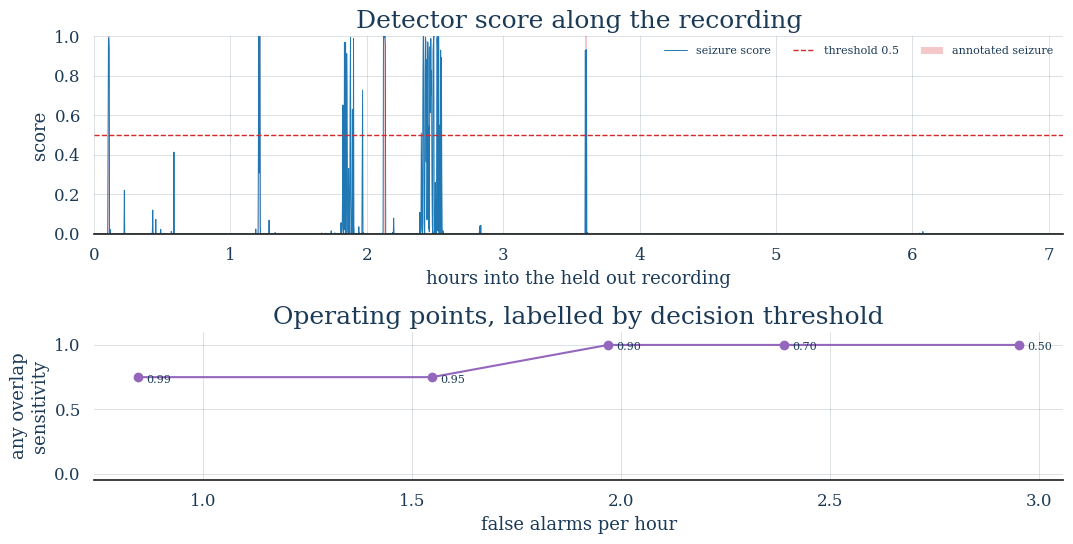

In [27]:
if RUN_EPILEPSY:
    figure, axes = plt.subplots(2, 1, figsize=(11, 5.6),
                                gridspec_kw={"height_ratios": [2, 1.5]})

    hours = np.arange(len(scores)) * CHBMIT_WINDOW_SECONDS / 3600
    axes[0].plot(hours, scores, linewidth=0.7, color="tab:blue", label="seizure score")
    axes[0].axhline(0.5, color="tab:red", linestyle="--", linewidth=1, label="threshold 0.5")

    labelled = False
    run_start = None
    for i, value in enumerate(list(yte) + [0]):        # shade the annotated seizures
        if value and run_start is None:
            run_start = i
        elif not value and run_start is not None:
            axes[0].axvspan(run_start * CHBMIT_WINDOW_SECONDS / 3600,
                            i * CHBMIT_WINDOW_SECONDS / 3600,
                            color="tab:red", alpha=0.25, linewidth=0,
                            label=None if labelled else "annotated seizure")
            labelled = True
            run_start = None

    axes[0].set_ylabel("score")
    axes[0].set_xlabel("hours into the held out recording")
    axes[0].set_xlim(0, hours[-1] if len(hours) else 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Detector score along the recording")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right", ncol=3)

    sweep_frame = pd.DataFrame(sweep)
    axes[1].plot(sweep_frame["false_alarms_per_hour"],
                 sweep_frame["any_overlap_sensitivity"], marker="o", color="tab:purple")
    for _, row in sweep_frame.iterrows():
        axes[1].annotate(f"{row['threshold']:.2f}",
                         (row["false_alarms_per_hour"], row["any_overlap_sensitivity"]),
                         textcoords="offset points", xytext=(6, -4), fontsize=8)
    axes[1].set_xlabel("false alarms per hour")
    axes[1].set_ylabel("any overlap\nsensitivity")
    axes[1].set_ylim(-0.05, 1.1)
    axes[1].set_title("Operating points, labelled by decision threshold")
    figure.tight_layout()
    plt.show()
else:
    print("Section 7d was skipped, so there is nothing to plot here.")


## 8. How this differs from the published results

One fold, one seed, and by default a subset of subjects. Every difference, in one place:

**Scale.** `SUBJECT_LIMIT` and `LIMIT_BATCHES` are small so this runs in minutes. Set both
to `None` for the full fold 0. The paper averages folds 0-4 and seeds 0-2; loop `FOLD` over
`range(5)` to match.

**Models.** Without `artifacts/`, the EEG side is CBraMod alone. REVE, NeuroLM, LaBraM,
BIOT, EEGPT and the supervised baselines need undistributed weights. If you have them, drop
them under `artifacts/models/` and add their identifiers to `MODELS` in section 4.

**CBraMod windowing.** Three 10 second windows concatenated, where the harness applies the
registry's `runtime_overrides` — so CBraMod differs from the paper even at full scale.

**CHB-MIT stands in for TUSZ**, so epilepsy values are not comparable to the paper's.

**Class balance.** Section 7d uses `balance="none"` so false alarms per hour is measured
against real elapsed time.

**Hypnogram features.** Five here, 34 in the harness.

**Environment.** The committed executed copy was run in an environment that
differs from `requirements-fm.txt` on 8 of its 26 pins, numpy and pandas by a
major version. Section 0 prints the versions actually used, so you can see what
produced the numbers you are reading. Install the pins if you want to match the
paper's stack rather than merely run the notebook.

### Going further

* `python reproduction/build_notebook.py` regenerates this notebook — edit the generator,
  not the `.ipynb`.
* `run/default_runs.sh` lists every experiment the paper reports; `src/entrypoints/` holds the
  five verbs that produced the paper's tables.
* Run `check_subject_grouping` against any fold manifest you add. It catches the split bug
  from section 1.
